# Лабораторная работа 1
## Анализ данных с Pandas и визуализация

**Цель:** освоить базовые операции библиотеки Pandas и построение графиков средствами Matplotlib/Seaborn.

Датасет о продажах генерируется воспроизводимо, поэтому ноутбук запускается без внешних ссылок и закрытых файлов.

In [1]:
import os
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".matplotlib"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 20)
DATA_DIR = ROOT / "data"
FIG_DIR = ROOT / "outputs" / "figures"
DATA_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"Проект: {ROOT.resolve()}")

Проект: C:\Users\Leonid\Documents\Codex\2026-09-23\new-chat


## 1. Загрузка и сохранение данных

Создадим набор из 120 заказов. Пропуски добавлены специально, чтобы показать их обработку.

In [2]:
rng = np.random.default_rng(42)
n = 120
dates = pd.date_range("2025-01-01", periods=180, freq="D")
categories = np.array(["Ноутбуки", "Смартфоны", "Аксессуары", "Мониторы"])
regions = np.array(["Центр", "Север", "Юг", "Запад"])
df = pd.DataFrame({
    "order_id": np.arange(1001, 1001 + n),
    "date": rng.choice(dates, size=n, replace=True),
    "region": rng.choice(regions, size=n),
    "category": rng.choice(categories, size=n),
    "units": rng.integers(1, 10, size=n),
    "price": rng.choice([35, 49, 79, 129, 299, 549, 899], size=n),
    "discount": rng.choice([0.00, 0.05, 0.10, 0.15], size=n),
})
df["revenue"] = (df["units"] * df["price"] * (1 - df["discount"])).round(2)
df["profit"] = (df["revenue"] * rng.uniform(0.08, 0.28, size=n)).round(2)
df.loc[rng.choice(df.index, size=5, replace=False), "region"] = pd.NA
df.loc[rng.choice(df.index, size=5, replace=False), "discount"] = np.nan
df = df.sort_values("date").reset_index(drop=True)
source_path = DATA_DIR / "sales_raw.csv"
df.to_csv(source_path, index=False)
df.head()

,order_id,date,region,category,units,price,discount,revenue,profit
0,1104,2025-01-02,Центр,Аксессуары,4,35,0.00,140.00,19.64
1,1117,2025-01-07,Юг,Ноутбуки,8,299,0.10,2152.80,356.46
2,1056,2025-01-08,Север,Аксессуары,7,49,0.10,308.70,39.56
3,1036,2025-01-12,Юг,Смартфоны,8,35,0.10,252.00,43.06
4,1045,2025-01-13,Север,Смартфоны,5,79,0.15,335.75,93.81


In [3]:
loaded = pd.read_csv(source_path, parse_dates=["date"])
print(f"Файл сохранён и загружен: {source_path}")
print(f"Размер таблицы: {loaded.shape}")
loaded.head(3)

Файл сохранён и загружен: C:\Users\Leonid\Documents\Codex\2026-09-23\new-chat\data\sales_raw.csv
Размер таблицы: (120, 9)


,order_id,date,region,category,units,price,discount,revenue,profit
0,1104,2025-01-02,Центр,Аксессуары,4,35,0.0,140.0,19.64
1,1117,2025-01-07,Юг,Ноутбуки,8,299,0.1,2152.8,356.46
2,1056,2025-01-08,Север,Аксессуары,7,49,0.1,308.7,39.56


## 2. Основные сведения о DataFrame

Здесь показаны форма таблицы, типы данных, диапазон дат, названия колонок и отдельные строки/столбцы.

In [4]:
print("Размер: " , loaded.shape)
print("Индекс: " , loaded.index)
print("Колонки: " , loaded.columns.tolist())
print("Типы: ")
print(loaded.dtypes)
print("Диапазон дат: " , loaded["date"].min().date(), "—", loaded["date"].max().date())
loaded.info()

Размер:  (120, 9)
Индекс:  RangeIndex(start=0, stop=120, step=1)
Колонки:  ['order_id', 'date', 'region', 'category', 'units', 'price', 'discount', 'revenue', 'profit']
Типы: 
order_id             int64
date        datetime64[ns]
region              object
category            object
units                int64
price                int64
discount           float64
revenue            float64
profit             float64
dtype: object
Диапазон дат:  2025-01-02 — 2025-06-25
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   order_id  120 non-null    int64         
 1   date      120 non-null    datetime64[ns]
 2   region    115 non-null    object        
 3   category  120 non-null    object        
 4   units     120 non-null    int64         
 5   price     120 non-null    int64         
 6   discount  115 non-null    float64       
 7   reven

In [5]:
print("Первые две строки:")
display(loaded.head(2))
print("Последняя строка:")
display(loaded.tail(1))
print("Выбранные столбцы:")
display(loaded[["date", "category", "revenue"]].head())
print("Описательная статистика числовых полей:")
display(loaded.describe().round(2))

Первые две строки:


,order_id,date,region,category,units,price,discount,revenue,profit
0,1104,2025-01-02,Центр,Аксессуары,4,35,0.0,140.0,19.64
1,1117,2025-01-07,Юг,Ноутбуки,8,299,0.1,2152.8,356.46


Последняя строка:


,order_id,date,region,category,units,price,discount,revenue,profit
119,1012,2025-06-25,Юг,Смартфоны,6,899,0.05,5124.3,687.2


Выбранные столбцы:


,date,category,revenue
0,2025-01-02,Аксессуары,140.00
1,2025-01-07,Ноутбуки,2152.80
2,2025-01-08,Аксессуары,308.70
3,2025-01-12,Смартфоны,252.00
4,2025-01-13,Смартфоны,335.75


Описательная статистика числовых полей:


,order_id,date,units,price,discount,revenue,profit
count,120.00,120,120.00,120.00,115.00,120.00,120.00
mean,1060.50,2025-04-04 02:00:00,4.89,314.38,0.08,1524.16,257.63
min,1001.00,2025-01-02 00:00:00,1.00,35.00,0.00,29.75,3.41
25%,1030.75,2025-02-20 12:00:00,2.00,49.00,0.05,220.20,38.98
50%,1060.50,2025-04-04 00:00:00,5.00,129.00,0.10,480.38,94.90
75%,1090.25,2025-05-19 06:00:00,7.00,549.00,0.10,2087.90,409.18
max,1120.00,2025-06-25 00:00:00,9.00,899.00,0.15,8091.00,1909.96
std,34.79,NaN,2.76,317.29,0.05,2035.85,364.33


## 3. Преобразование, группировка, сортировка и очистка

Демонстрируются создание новых столбцов, группировка и агрегация, сортировка, удаление строк/колонок, обработка пропущенных значений.

In [6]:
work = loaded.copy()
work["month"] = work["date"].dt.to_period("M").astype(str)
work["avg_unit_price"] = (work["revenue"] / work["units"]).round(2)
work["is_large_order"] = work["revenue"] >= work["revenue"].quantile(0.75)
work = work.sort_values(["revenue", "date"], ascending=[False, True])
category_summary = (work.groupby("category", dropna=False)
    .agg(orders=("order_id", "count"), units=("units", "sum"),
         revenue=("revenue", "sum"), profit=("profit", "sum"))
    .assign(profit_margin=lambda x: (x["profit"] / x["revenue"] * 100).round(2))
    .sort_values("revenue", ascending=False))
display(category_summary.round(2))
print("Самые крупные заказы:")
display(work.loc[work["is_large_order"], ["order_id", "category", "revenue", "profit"]].head())

,orders,units,revenue,profit,profit_margin
category,,,,,
Ноутбуки,32,168,57524.45,10761.97,18.71
Смартфоны,32,170,54612.15,9458.71,17.32
Аксессуары,29,150,46847.90,6496.48,13.87
Мониторы,27,99,23914.70,4198.22,17.55


Самые крупные заказы:


,order_id,category,revenue,profit
19,1023,Смартфоны,8091.00,1909.96
24,1078,Аксессуары,8091.00,1463.71
96,1106,Смартфоны,7281.90,1601.69
69,1099,Ноутбуки,7192.00,1703.18
43,1091,Аксессуары,6877.35,608.44


In [7]:
print("Пропуски до очистки:")
display(work.isna().sum().to_frame("missing").T)
clean = work.dropna(subset=["region"]).copy()
clean["discount"] = clean["discount"].fillna(clean["discount"].median())
clean = clean.drop(columns=["is_large_order"])
clean_path = DATA_DIR / "sales_clean.csv"
clean.to_csv(clean_path, index=False)
print(f"Удалено строк с неизвестным регионом: {len(work) - len(clean)}")
print("Пропуски после очистки:")
display(clean.isna().sum().to_frame("missing").T)
print(f"Очищенный файл: {clean_path}")

Пропуски до очистки:


,order_id,date,region,category,units,price,discount,revenue,profit,month,avg_unit_price,is_large_order
missing,0,0,5,0,0,0,5,0,0,0,0,0


Удалено строк с неизвестным регионом: 5
Пропуски после очистки:


,order_id,date,region,category,units,price,discount,revenue,profit,month,avg_unit_price
missing,0,0,0,0,0,0,0,0,0,0,0


Очищенный файл: C:\Users\Leonid\Documents\Codex\2026-09-23\new-chat\data\sales_clean.csv


## 4. Визуализация

Все рисунки сохраняются в `outputs/figures/`. Использованы line plot, bar chart, histogram, boxplot, scatter, pairplot, heatmap и pie chart.

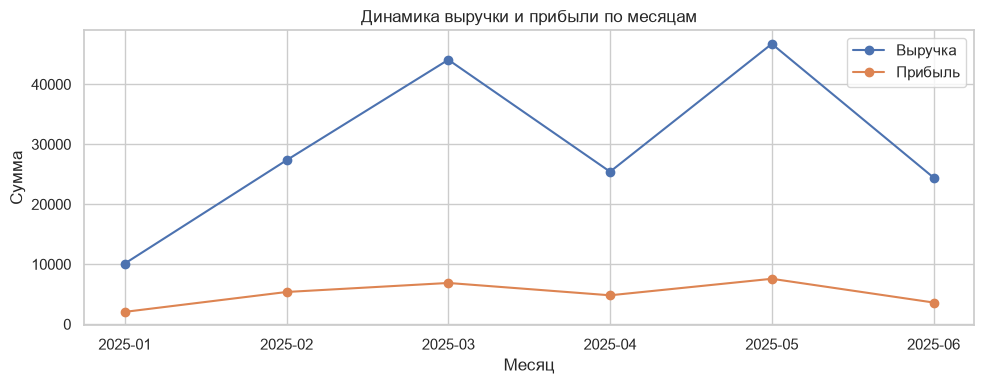

In [8]:
monthly = clean.groupby("month", as_index=False).agg(revenue=("revenue", "sum"), profit=("profit", "sum"))
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly["month"], monthly["revenue"], marker="o", label="Выручка")
ax.plot(monthly["month"], monthly["profit"], marker="o", label="Прибыль")
ax.set(title="Динамика выручки и прибыли по месяцам", xlabel="Месяц", ylabel="Сумма")
ax.legend(); fig.tight_layout(); fig.savefig(FIG_DIR / "01_line_plot.png", dpi=140); plt.show()

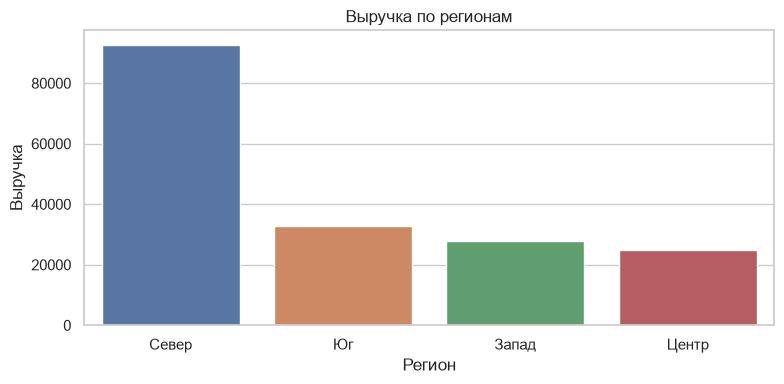

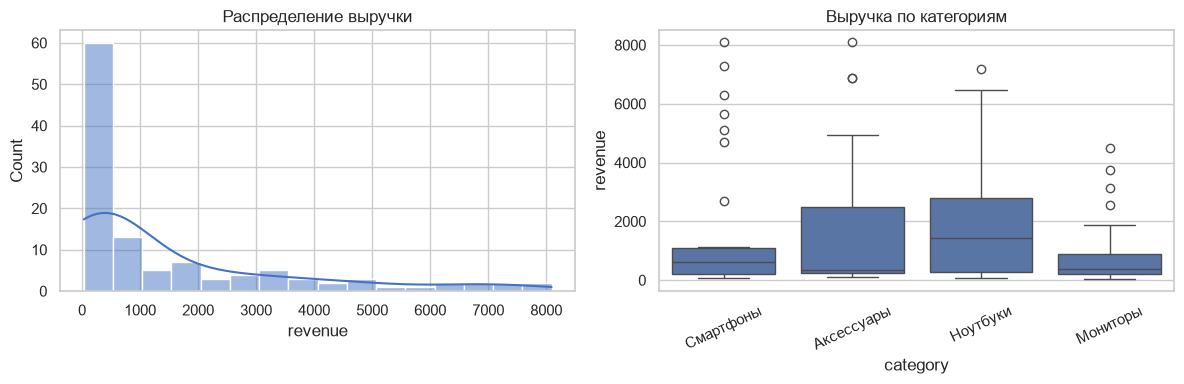

In [9]:
region_summary = clean.groupby("region", as_index=False)["revenue"].sum().sort_values("revenue", ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=region_summary, x="region", y="revenue", ax=ax, hue="region", legend=False)
ax.set(title="Выручка по регионам", xlabel="Регион", ylabel="Выручка"); fig.tight_layout()
fig.savefig(FIG_DIR / "02_bar_chart.png", dpi=140); plt.show()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=clean, x="revenue", bins=16, kde=True, ax=axes[0], color="#4472C4")
axes[0].set(title="Распределение выручки")
sns.boxplot(data=clean, x="category", y="revenue", ax=axes[1])
axes[1].tick_params(axis="x", rotation=25); axes[1].set(title="Выручка по категориям")
fig.tight_layout(); fig.savefig(FIG_DIR / "03_histogram_boxplot.png", dpi=140); plt.show()

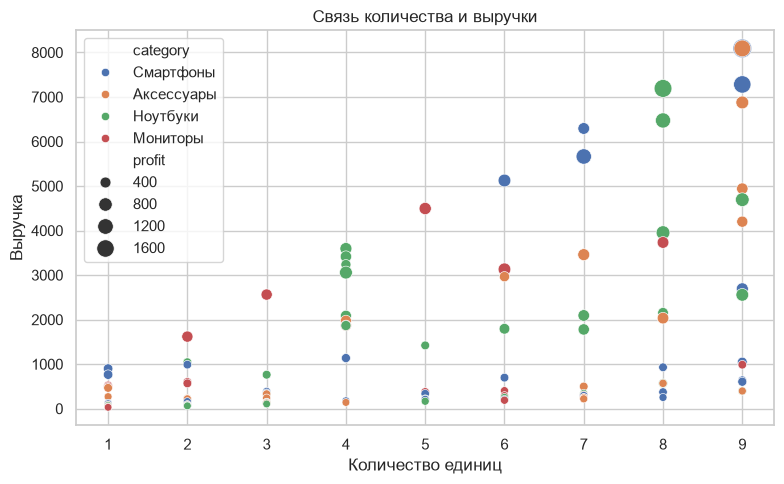

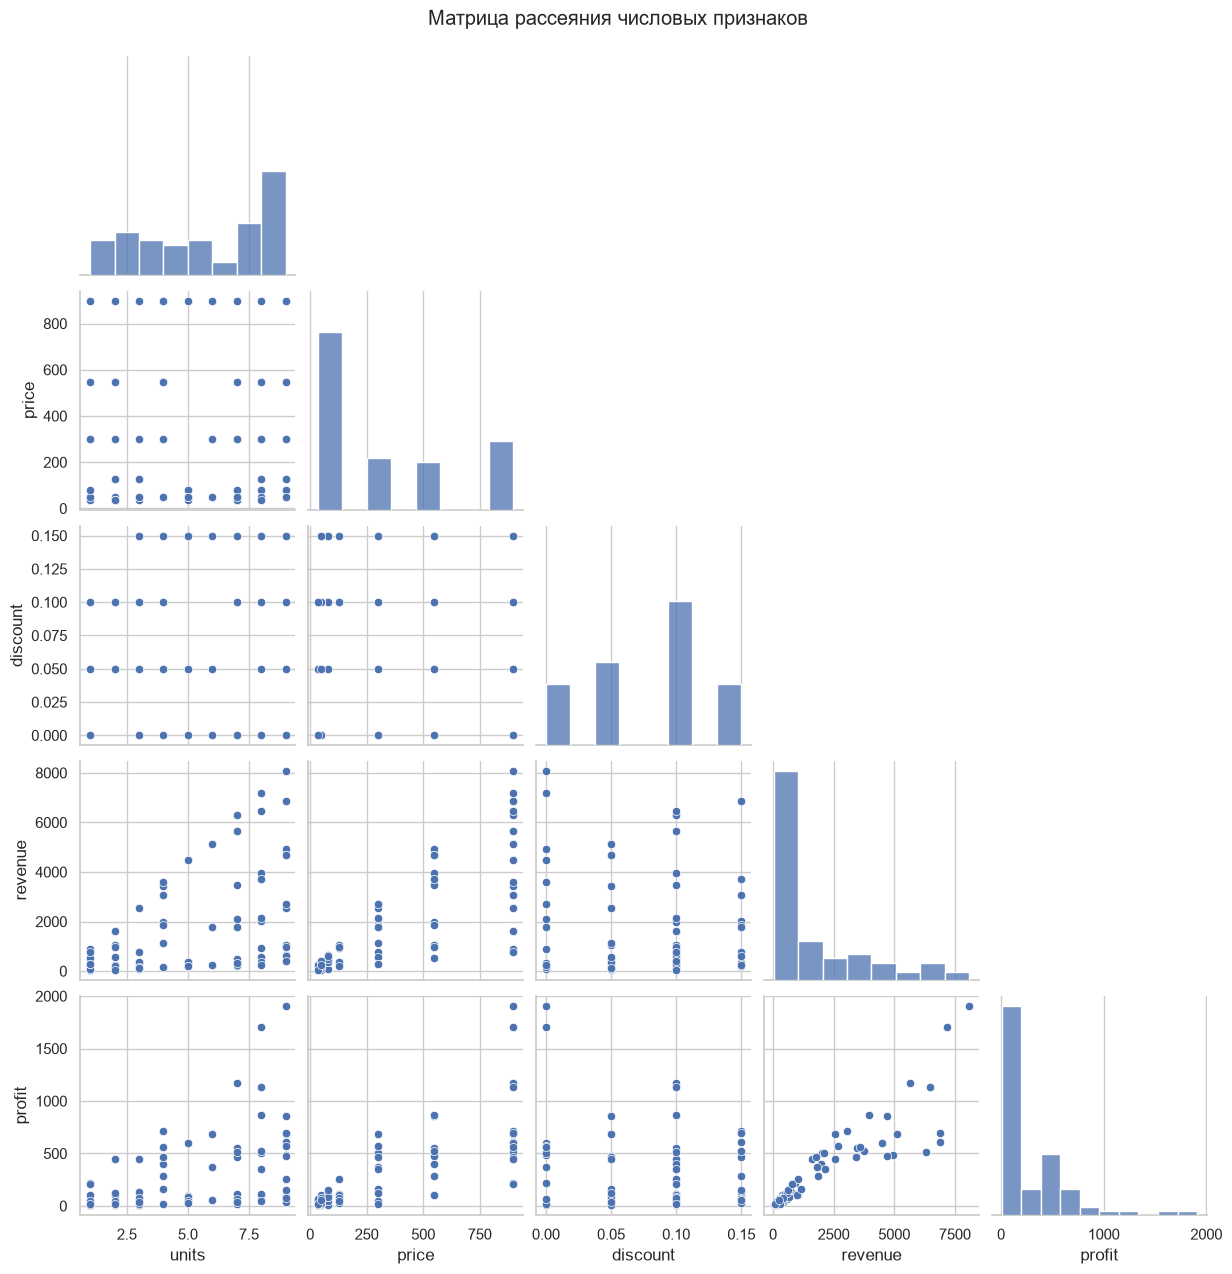

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=clean, x="units", y="revenue", hue="category", size="profit", sizes=(30, 180), ax=ax)
ax.set(title="Связь количества и выручки", xlabel="Количество единиц", ylabel="Выручка"); fig.tight_layout()
fig.savefig(FIG_DIR / "04_scatter.png", dpi=140); plt.show()
pair_data = clean[["units", "price", "discount", "revenue", "profit"]]
pair = sns.pairplot(pair_data.sample(min(80, len(pair_data)), random_state=42), corner=True)
pair.fig.suptitle("Матрица рассеяния числовых признаков", y=1.02); pair.savefig(FIG_DIR / "05_pairplot.png", dpi=120); plt.show()

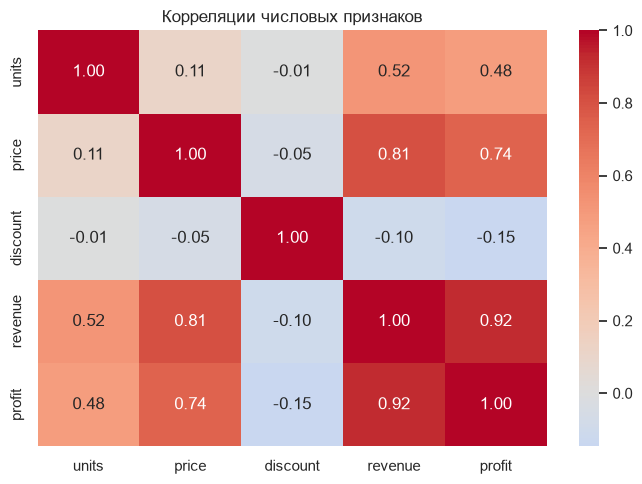

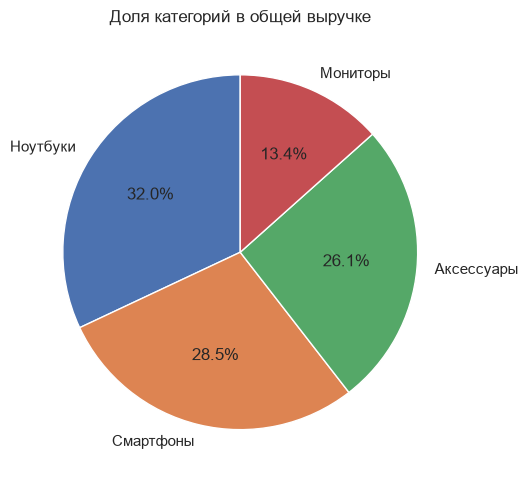

In [11]:
corr = clean[["units", "price", "discount", "revenue", "profit"]].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set(title="Корреляции числовых признаков"); fig.tight_layout()
fig.savefig(FIG_DIR / "06_heatmap.png", dpi=140); plt.show()
category_revenue = clean.groupby("category")["revenue"].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 5))
ax.pie(category_revenue, labels=category_revenue.index, autopct="%1.1f%%", startangle=90)
ax.set_title("Доля категорий в общей выручке"); fig.tight_layout()
fig.savefig(FIG_DIR / "07_pie.png", dpi=140); plt.show()

## 5. Выводы

1. Pandas удобно использовать для загрузки, очистки, преобразования, группировки и сохранения табличных данных.
2. Группировка по категории и региону позволяет сравнить вклад сегментов в выручку и прибыль.
3. Графики помогают увидеть динамику, распределения, выбросы и взаимосвязи между признаками.
4. Перед анализом пропуски необходимо обработать: удалить строки, если значение критично, или заменить статистикой, если это допустимо.

## 6. Ответы на контрольные вопросы

1. **Искусственный интеллект** — методы и системы, которые выполняют задачи, требующие элементов человеческого интеллекта: восприятия, обучения, рассуждения и принятия решений.
2. **Сильный ИИ** гипотетически способен решать широкий класс интеллектуальных задач на уровне человека и осознавать себя; **слабый ИИ** решает ограниченный набор прикладных задач без универсального интеллекта.
3. Обычно выделяют символические методы, методы машинного обучения, нейросетевые методы, эволюционные алгоритмы и методы поиска/оптимизации.
4. Сложность построения интеллектуальных систем связана с формализацией знаний, неоднозначностью реального мира, качеством данных, объяснимостью и проверкой результатов.
5. Основная задача науки о данных — извлекать из данных проверяемые закономерности и полезные для принятия решений выводы.
6. Нужны математическая и статистическая подготовка, программирование, знание предметной области, умение работать с базами данных и навыки визуализации/коммуникации результатов.
7. Данные должны быть релевантными, достаточно полными, точными, непротиворечивыми, актуальными и репрезентативными для поставленной задачи.
8. Графики используются для исследования структуры данных, сравнения групп, поиска трендов, выбросов, зависимостей и понятной передачи результатов.
9. Примеры типов графиков: линейная, столбчатая и круговая диаграммы, гистограмма, boxplot, scatter plot, pairplot, heatmap.
10. Линейные графики показывают динамику, столбчатые — сравнение категорий, гистограммы — распределение, boxplot — медиану и выбросы, scatter — связь признаков, heatmap — матрицу значений/корреляций.
11. Pandas — библиотека Python для анализа и обработки табличных и временных данных.
12. Основное назначение Pandas — предоставить Series и DataFrame, а также операции загрузки, очистки, преобразования, агрегации и сохранения данных.
13. Основные функции: `read_csv`, `head`, `info`, `describe`, `loc`, `iloc`, `drop`, `dropna`, `fillna`, `sort_values`, `groupby`, `agg`, `merge`, `to_csv`.
14. Matplotlib — библиотека Python для построения статических и интерактивных графиков.
15. Основное назначение Matplotlib — гибкая настройка визуализаций: осей, подписей, легенд, цветов, размеров и сохранения рисунков.
16. Основные функции и методы: `figure`, `subplots`, `plot`, `bar`, `hist`, `scatter`, `pie`, `savefig`, `show`, `set_title`, `set_xlabel`, `set_ylabel`, `legend`.
17. Python популярен для интеллектуальных систем благодаря простому синтаксису, богатой экосистеме библиотек, поддержке научных вычислений и машинного обучения, а также большому сообществу.